In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
dataset = np.loadtxt('diabetes.csv', delimiter=',', skiprows=1)
X = dataset[:,0:8]
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
loss_fn = nn.BCELoss() # binary cross-entropy

In [2]:
model = nn.Sequential(
    nn.Linear(8, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

In [3]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
n_epochs = 100
batch_size = 10
for epoch in range(n_epochs):
    for i in range(0, len(X), batch_size):
        Xbatch = X[i:i+batch_size]
        y_pred = model(Xbatch)
        ybatch = y[i:i+batch_size]
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Finished epoch {epoch}, latest loss {loss}')

Finished epoch 0, latest loss 0.6712665557861328
Finished epoch 1, latest loss 0.6383455395698547
Finished epoch 2, latest loss 0.5787800550460815
Finished epoch 3, latest loss 0.5201762318611145
Finished epoch 4, latest loss 0.49147844314575195
Finished epoch 5, latest loss 0.4748416543006897
Finished epoch 6, latest loss 0.45455944538116455
Finished epoch 7, latest loss 0.4506203234195709
Finished epoch 8, latest loss 0.4610128700733185
Finished epoch 9, latest loss 0.4590127468109131
Finished epoch 10, latest loss 0.46343743801116943
Finished epoch 11, latest loss 0.48173987865448
Finished epoch 12, latest loss 0.4903585910797119
Finished epoch 13, latest loss 0.4952728748321533
Finished epoch 14, latest loss 0.5026874542236328
Finished epoch 15, latest loss 0.5069226622581482
Finished epoch 16, latest loss 0.5111355781555176
Finished epoch 17, latest loss 0.4924774765968323
Finished epoch 18, latest loss 0.5166205763816833
Finished epoch 19, latest loss 0.5156590342521667
Finished 

In [4]:
i = 5
X_sample = X[i:i+1]
model.eval()
with torch.no_grad():
  y_pred = model(X_sample)
print(f"{X_sample[0]} -> {y_pred[0]}")

tensor([  5.0000, 116.0000,  74.0000,   0.0000,   0.0000,  25.6000,   0.2010,
         30.0000]) -> tensor([0.3083])


In [5]:
model.eval()
with torch.no_grad():
  y_pred = model(X)

In [6]:
accuracy = (y_pred.round() == y).float().mean()
print(f"Accuracy {accuracy}")

Accuracy 0.79296875


100%|██████████| 170M/170M [00:03<00:00, 43.3MB/s]


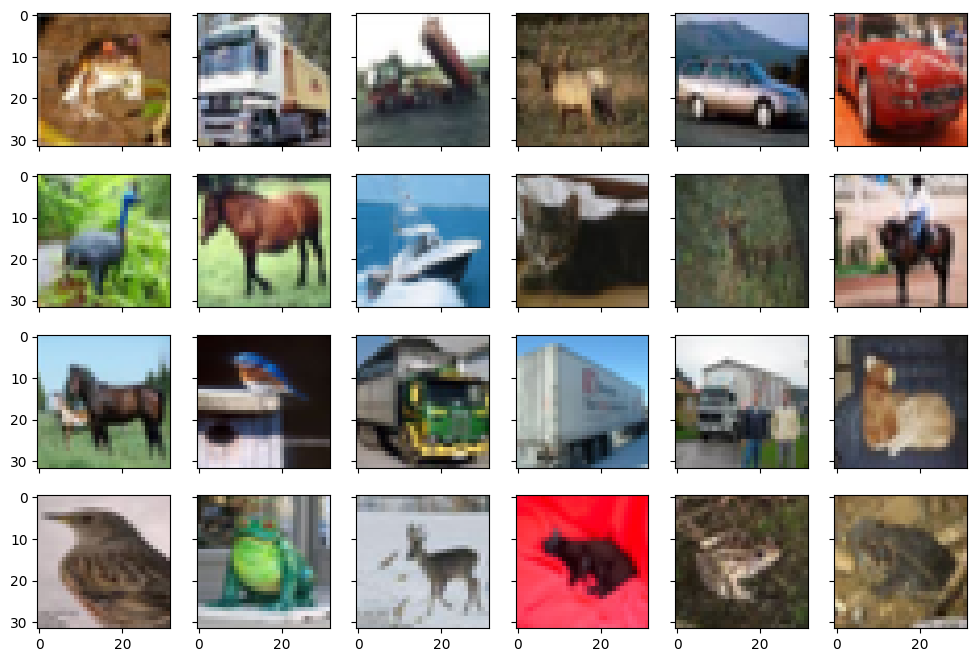

In [7]:
import matplotlib.pyplot as plt
import torchvision
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
fig, ax = plt.subplots(4, 6, sharex=True, sharey=True, figsize=(12,8))
for i in range(0, 24):
  row, col = i//6, i%6
  ax[row][col].imshow(trainset.data[i])
plt.show()

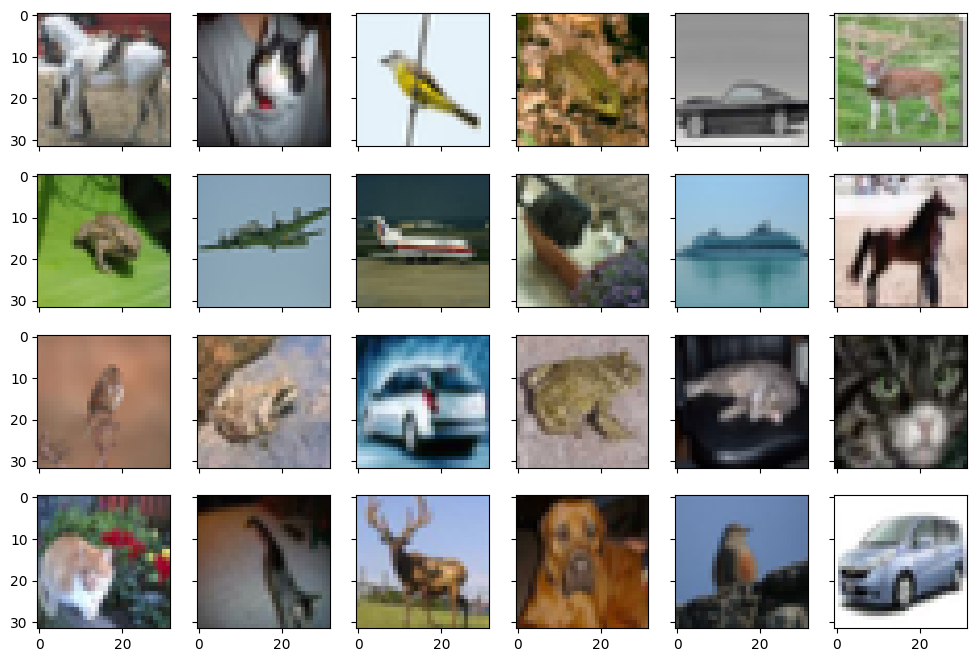

In [8]:
import matplotlib.pyplot as plt
import torchvision
import torch
from torchvision.datasets import CIFAR10
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
trainset = CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = CIFAR10(root='./data', train=False, download=True, transform=transform)
batch_size = 24
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True)
fig, ax = plt.subplots(4, 6, sharex=True, sharey=True, figsize=(12,8))
for images, labels in trainloader:
  for i in range(batch_size):
    row, col = i//6, i%6
    ax[row][col].imshow(images[i].numpy().transpose([1,2,0]))
  break # take only the first batch
plt.show()

In [9]:
import torch.nn as nn
model = nn.Sequential(
  nn.Conv2d(3, 32, kernel_size=(3,3), stride=1, padding=1),
  nn.ReLU(),
  nn.Dropout(0.3),
  nn.Conv2d(32, 32, kernel_size=(3,3), stride=1, padding=1),
  nn.ReLU(),
  nn.MaxPool2d(kernel_size=(2, 2)),
  nn.Flatten(),
  nn.Linear(8192, 512),
  nn.ReLU(),
  nn.Dropout(0.5),
  nn.Linear(512, 10)
)
print(model)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=8192, out_features=512, bias=True)
  (8): ReLU()
  (9): Dropout(p=0.5, inplace=False)
  (10): Linear(in_features=512, out_features=10, bias=True)
)


In [10]:
import torch.nn as nn
import torch.optim as optim
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
n_epochs = 20
for epoch in range(n_epochs):
  model.train()
  for inputs, labels in trainloader:
    y_pred = model(inputs)
    loss = loss_fn(y_pred, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  acc = 0
  count = 0
  model.eval()
  with torch.no_grad():
    for inputs, labels in testloader:
      y_pred = model(inputs)
      acc += (torch.argmax(y_pred, 1) == labels).float().sum()
      count += len(labels)
  acc /= count
  print("Epoch %d: model accuracy %.2f%%" % (epoch, acc*100))

Epoch 0: model accuracy 38.42%
Epoch 1: model accuracy 46.17%
Epoch 2: model accuracy 49.82%
Epoch 3: model accuracy 52.26%
Epoch 4: model accuracy 54.76%
Epoch 5: model accuracy 56.52%
Epoch 6: model accuracy 56.86%
Epoch 7: model accuracy 59.60%
Epoch 8: model accuracy 60.76%
Epoch 9: model accuracy 61.92%
Epoch 10: model accuracy 62.03%
Epoch 11: model accuracy 62.97%
Epoch 12: model accuracy 64.76%
Epoch 13: model accuracy 65.59%
Epoch 14: model accuracy 66.12%
Epoch 15: model accuracy 67.13%
Epoch 16: model accuracy 67.79%
Epoch 17: model accuracy 68.47%
Epoch 18: model accuracy 68.57%
Epoch 19: model accuracy 68.37%


In [11]:
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
n_epochs = 20
for epoch in range(n_epochs):
  model.train()
  for inputs, labels in trainloader:
    y_pred = model(inputs.to(device))
    loss = loss_fn(y_pred, labels.to(device))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  acc = 0
  count = 0
  model.eval()
  with torch.no_grad():
    for inputs, labels in testloader:
      y_pred = model(inputs.to(device))
      acc += (torch.argmax(y_pred, 1) == labels.to(device)).float().sum()
      count += len(labels)
  acc /= count
  print("Epoch %d: model accuracy %.2f%%" % (epoch, acc*100))

Epoch 0: model accuracy 68.74%
Epoch 1: model accuracy 69.43%
Epoch 2: model accuracy 68.72%
Epoch 3: model accuracy 68.89%
Epoch 4: model accuracy 70.19%
Epoch 5: model accuracy 69.85%
Epoch 6: model accuracy 70.13%
Epoch 7: model accuracy 70.09%
Epoch 8: model accuracy 69.96%
Epoch 9: model accuracy 70.62%
Epoch 10: model accuracy 70.55%
Epoch 11: model accuracy 70.38%
Epoch 12: model accuracy 70.14%
Epoch 13: model accuracy 70.71%
Epoch 14: model accuracy 70.46%
Epoch 15: model accuracy 70.23%
Epoch 16: model accuracy 70.67%
Epoch 17: model accuracy 70.86%
Epoch 18: model accuracy 70.99%
Epoch 19: model accuracy 70.98%
